# Final Project Draft:

**Author**: Madison Zorman

**Date**: 4/18/2026

## 1. Problem Statement & Dataset


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA

## 2. Data Loading & Exploration

In [2]:
df= pd.read_csv(r"data\raw\synthetic_fraud_dataset.csv")

#feature names list
feature_names = df.columns.tolist()
print('Feature names in the dataset:\n', feature_names)

df.head()

Feature names in the dataset:
 ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Timestamp', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age', 'Transaction_Distance', 'Authentication_Method', 'Risk_Score', 'Is_Weekend', 'Fraud_Label']


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [3]:
print (df.info())

print (df.shape)

# data set shape 50000 rows (0-49999) and 21 columns

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Timestamp                     50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  Failed_Trans

In [4]:
#Target variable distribution - Fraud_Label
target= df['Fraud_Label']
target_counts= target.value_counts()
print('Value counts for Fraud_Label:\n', target_counts)

print('0 - Not Fraud \n1 - Fraud')

# 0 - Not Fraud
# 1 - Fraud

Value counts for Fraud_Label:
 Fraud_Label
0    33933
1    16067
Name: count, dtype: int64
0 - Not Fraud 
1 - Fraud


In [5]:
#null counts
print (df.isnull().sum())

#dulicate counts
print( 'duplicate counts:\n', df.duplicated().sum())


#no missing values in the found in the dataset

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64
duplicate counts:
 0


In [6]:
# summery for referencing
# - 50000 rows and 21 columns
# - columns: ['Transaction_ID', 'User_ID', 'Transaction_Amount',
#            'Transaction_Type', 'Timestamp', 'Account_Balance',
#            'Device_Type', 'Location', 'Merchant_Category',
#            'IP_Address_Flag', 'Previous_Fraudulent_Activity',
#            'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
#            'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
#            'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
#            'Is_Weekend', 'Fraud_Label']
# - no missing values in the dataset
# - target variable is 'Fraud_Label' with 2 classes (0 - Not Fraud, 1 - Fraud)


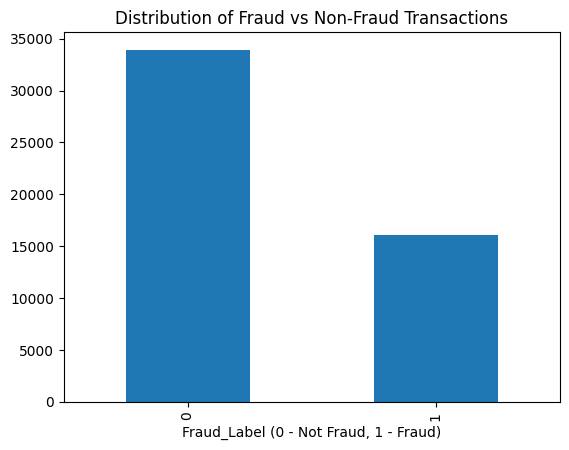

In [7]:
#visualization 1 - distribution of fraud vs non-fraud transactions - bar
 
target_counts.plot(kind='bar')
plt.title('Distribution of Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud_Label (0 - Not Fraud, 1 - Fraud)')
plt.show()

#more non fraud transactions than fraud transactions, indicating class imbalance in the dataset.

Merchant_Category
Restaurants    3255
Travel         3235
Groceries      3217
Clothing       3181
Electronics    3179
Name: count, dtype: int64


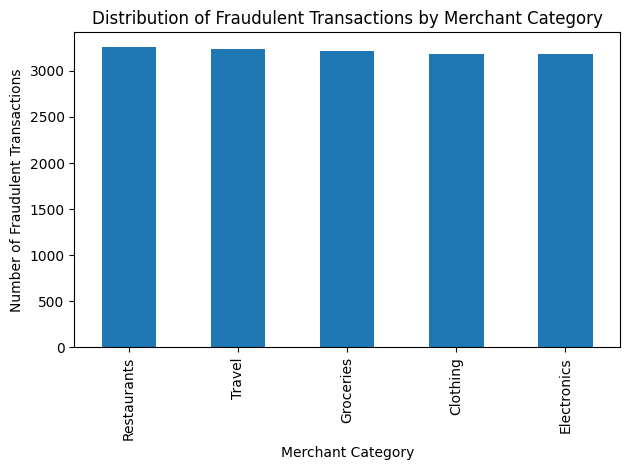

In [8]:
#visualization 2 - merchant category fraudulent transaction distribution - bar

fraud_merchant_counts = df[df['Fraud_Label'] == 1]['Merchant_Category'].value_counts()
print(fraud_merchant_counts)

fraud_merchant_counts.plot(kind='bar')
plt.title('Distribution of Fraudulent Transactions by Merchant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Number of Fraudulent Transactions')

plt.tight_layout()
plt.show()

#resaurants experince the highest level of fraud

Location
Tokyo       3315
New York    3221
Sydney      3194
London      3181
Mumbai      3156
Name: count, dtype: int64


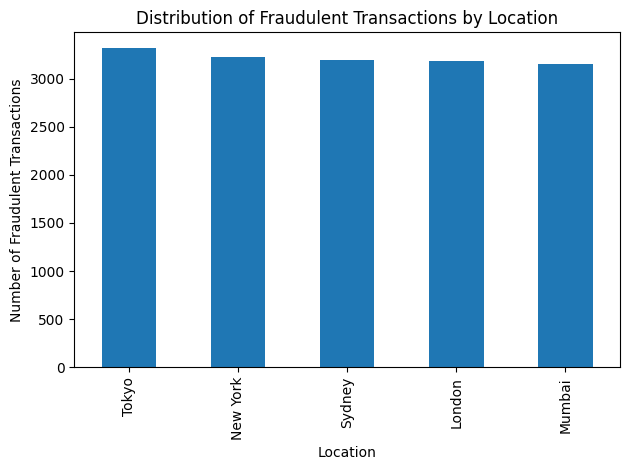

In [9]:
# visualization 3 - location distribution of fraudulent transactions - bar      

fraud_location_counts = df[df['Fraud_Label'] == 1]['Location'].value_counts()
print (fraud_location_counts) 

fraud_location_counts.plot(kind='bar')
plt.title('Distribution of Fraudulent Transactions by Location')
plt.xlabel('Location')
plt.ylabel('Number of Fraudulent Transactions')
plt.tight_layout()
plt.show()


### Section 2 Markdown

From my initial analysis of the data set, I found that it consists of 21 features and 50,000 observations. Overall, the dataset was very clean; there were no null values or duplicates present. I also found that there is a large class imbalance between the Fraud and Non-Fraud observations. Because of this, it will be imperative to ensure that the data is split with equal weight for the training and testing.


## 3. Feature Engineering


In [10]:
#engineered feature 1 - amount to balance ratio
# - identify overdrafts by negative values
# - identifies large transactions 


df['Amount_to_Balance_Ratio'] = df['Transaction_Amount'] / (df['Account_Balance'] + 1)

##################################################
#engineered feature 2 - ammount deiviation from 7 day average
# - identifies large transactions compared to recent history

df['Amount_Diff_from_7d_Avg'] = df['Avg_Transaction_Amount_7d'] - df['Transaction_Amount']  

##################################################
#engineered feature 3 - device distance and card age risk factor
# - identifies risk based on distance and card age
df['device_distance_age_risk'] = df['Transaction_Distance'] * (df['Card_Age'] )

##################################################
#engineered feature 3 - measurs the transactions difference from the average amount for the user\
#same as Amount_Diff_from_7d_Avg but calculated from all ofthe users recorded transactions

df['user_transaction_avg_diff'] =  df.groupby('User_ID')['Transaction_Amount'].transform('mean')-df['Transaction_Amount']

##################################################
#engineered feature 4 - increases severity for high transactions for every failed transaction in the last 7 days
# if user had any failed transaction in the last 7 days the sevarity of high transactions will be increadsed

df['7d_severity'] = df['Failed_Transaction_Count_7d'] * df['Amount_to_Balance_Ratio']

##################################################
#engineered feature 5 - card type and age risk factor
# - identifies risk based on card type and age

df['card_type_age'] = (df['Card_Type'].astype('category').cat.codes) + (df['Card_Age']/100)




In [11]:
df.head()
#print(df['Failed_Transaction_Count_7d'].describe())
#df['Failed_Transaction_Count_7d'].value_counts()

#=balance-7dayavg*failed transactions

#df['user_transaction'] =  df.groupby('User_ID')['Transaction_Amount'].transform('mean')
#df['User_ID'].value_counts()

#user6599=df[df['User_ID'] == 'USER_6599']
#print(user6599.sort_values('Timestamp'))


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,Amount_to_Balance_Ratio,Amount_Diff_from_7d_Avg,device_distance_age_risk,user_transaction_avg_diff,7d_severity,card_type_age
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,Biometric,0.8494,0,0,0.000427,397.84,57406.05,66.977143,0.001281,0.65
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,Password,0.0959,0,1,0.000016,477.57,409824.96,10.498000,0.000063,3.86
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,Biometric,0.8400,0,1,0.018214,21.05,431499.54,26.822500,0.072857,5.26
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,OTP,0.7935,0,1,0.003311,-71.84,99701.36,-92.467778,0.013244,3.76
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,Password,0.3819,1,1,0.000339,297.41,135377.20,39.960000,0.001355,3.40


In [12]:

print(df.info())
print('features names:\n', df.columns.tolist())

#maybee add later
#df['frequency_failed'] = df['Failed_Transaction_Count_7d'] / (df['Daily_Transaction_Count'])
#df['older_card_flag'] = (df['Card_Age'] > ... ).astype(int)
#df['device_distance_age_risk'] = df['Transaction_Distance'] / (df['Card_Age'])
#df['older_card_tranaction_count]= df['older_card_flag'] * df['Daily_Transaction_Count']

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Timestamp                     50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  Failed_Trans

### Section 3 Markdown


engineered feature 1 - amount to balance ratio:

Creates a ratio to compare the balance of the user's account to the amount of the transaction. I added this feature to identify relatively large transactions that may be a sign of fraud. 


engineered feature 2 - amount difference from 7-day average:

The purpose of this feature is to flag transaction amounts that differ significantly from the recent ones. It does this by calculating the difference between the transaction amount and the average amount of transactions within a 7-day period.


Engineered Feature 3 - difference from a user's average transaction amount

This feature is similar to Engineered Feature 2, except it uses the average amount of all transactions for a user instead of the 7-day average.


Engineered Feature 4 - increased severity for transactions when there were previously failed transactions for seven days prior

Failed transactions can be a strong predictor of fraud, and many of them may indicate repeated fraud. This feature takes the amount-to-balance ratio and multiplies it by the number of failed transactions during the week. This will increase the severity of any suspicious transactions.
 
 
Engineered Feature 5 - age of card type

Some card types may be more susceptible to fraud. This feature can help detect any relationship between each card type's age and the fraud rating.


## 4. Data Processing

In [13]:
# no null values  or duplicates where found. so there is no nneed to handle them
#['Fraud_Label', 'Transaction_ID', 'User_ID','Risk_Score', 'Previous_Fraudulent_Activity','IP_Address_Flag', 'Timestamp'])
# train split 80-20


Y = df['Fraud_Label']
X = df.drop(columns=['Fraud_Label', 'Transaction_ID', 'User_ID','Risk_Score', 'Previous_Fraudulent_Activity', 'Timestamp'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.35, random_state=42,stratify=Y)

# scalling and encoding for K means 

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Model 2: random forest with engineered features


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# predictions
rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

# evaluation
def rf_w_ef():
    print("Accuracy:", accuracy_score(y_test, rf_predictions))
    print("Precision:", precision_score(y_test, rf_predictions))
    print("Recall:", recall_score(y_test, rf_predictions))
    print("F1 Score:", f1_score(y_test, rf_predictions))
rf_w_ef()

Accuracy: 0.8782285714285715
Precision: 1.0
Recall: 0.621020807398186
F1 Score: 0.7662095447065277


In [29]:
#Feture importance analysis

Feature_Importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print('\ntop 20 feature importances:')
Feature_Importances.head(20)


top 20 feature importances:


Failed_Transaction_Count_7d        0.379722
7d_severity                        0.070661
Amount_to_Balance_Ratio            0.049064
Account_Balance                    0.041244
Transaction_Amount                 0.040755
user_transaction_avg_diff          0.040643
Transaction_Distance               0.040340
Amount_Diff_from_7d_Avg            0.039462
Avg_Transaction_Amount_7d          0.039136
device_distance_age_risk           0.038967
card_type_age                      0.037281
Card_Age                           0.035926
Daily_Transaction_Count            0.024458
Is_Weekend                         0.005695
Device_Type_Mobile                 0.005262
Device_Type_Tablet                 0.005213
Device_Type_Laptop                 0.005106
Authentication_Method_OTP          0.004934
Authentication_Method_Biometric    0.004931
Authentication_Method_Password     0.004889
dtype: float64

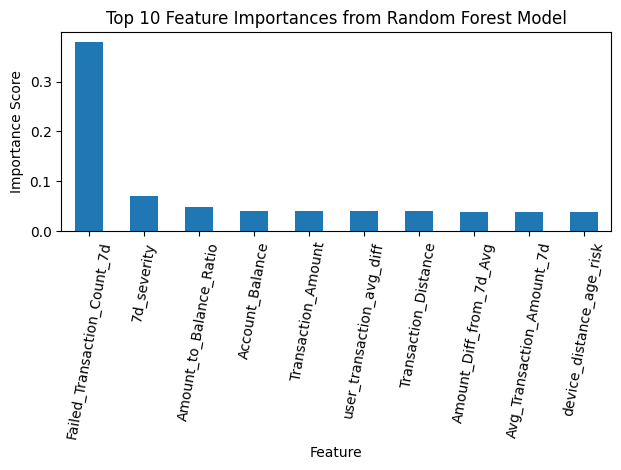

In [16]:
#top ten feature importance visualization

Feature_Importances.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances from Random Forest Model')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=80)


plt.tight_layout()
plt.show()   

## 6. Model 3: kmeans 

['Failed_Transaction_Count_7d', '7d_severity', 'Amount_to_Balance_Ratio', 'Account_Balance', 'Transaction_Amount', 'user_transaction_avg_diff', 'Transaction_Distance', 'Amount_Diff_from_7d_Avg']
k=2: inertia=209157.27
k=3: inertia=189031.23
k=4: inertia=158649.93
k=5: inertia=146261.99
k=6: inertia=137173.15
k=7: inertia=127887.44
k=8: inertia=115558.35
k=9: inertia=109428.16
k=10: inertia=104648.92


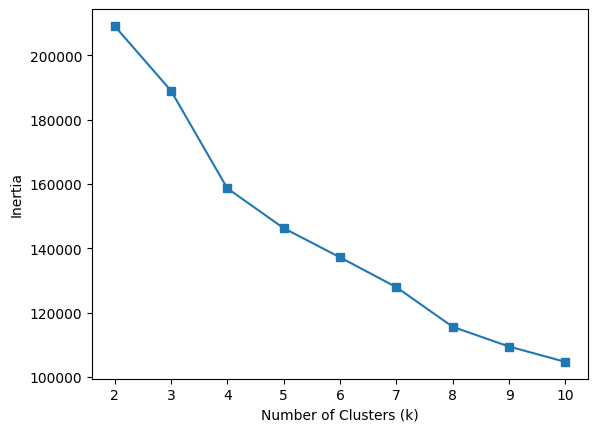

In [17]:
#finding optimal k

inertias = []
k_range = range(2, 11)

top_features = Feature_Importances.head(8).index.tolist()


print( top_features)

X_train_Top = X_train[top_features]
X_test_Top = X_test[top_features]

scaler = StandardScaler()
X_train_Top_scaled = scaler.fit_transform(X_train_Top)
X_test_Top_scaled = scaler.transform(X_test_Top)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_Top_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: inertia={kmeans.inertia_:.2f}")

plt.plot(k_range, inertias, marker='s')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [18]:
#k means clustering with k=

kmeans = KMeans(n_clusters=4, random_state=42)
train_clusters = kmeans.fit_predict(X_train_Top_scaled)
test_clusters = kmeans.predict(X_test_Top_scaled)

#cluster analysis table
X_train_kmeans = pd.DataFrame(X_train_Top_scaled, columns=X_train_Top.columns)
X_train_kmeans['Cluster'] = train_clusters
X_train_kmeans['Fraud_Label'] = y_train.values

#statistcs summary 
print('training clusters summary:')
cluster_summary_train = X_train_kmeans.groupby('Cluster')['Fraud_Label'].agg(['count', 'mean'])
print(cluster_summary_train)

print('test clusters summary:')
cluster_summary_test = pd.DataFrame({'Cluster': test_clusters, 'Fraud_Label': y_test.values}).groupby('Cluster')['Fraud_Label'].agg(['count', 'mean'])
print(cluster_summary_test)

print('training and test cluster mean comparison:')
cluster_summary_combined = cluster_summary_train.merge(cluster_summary_test, on='Cluster', suffixes=('_train', '_test')).drop(columns=['count_test', 'count_train'])
cluster_summary_combined['mean_diff'] = cluster_summary_combined['mean_train'] - cluster_summary_combined['mean_test']
 
print(cluster_summary_combined)


#count - number of transactions in that cluster
#mean - fraud rate in that cluster

#similar results for training and testing - overfitting and underfitting are not a problem

training clusters summary:
         count      mean
Cluster                 
0        13149  0.496083
1        13136  0.155146
2         6048  0.300595
3          167  0.389222
test clusters summary:
         count      mean
Cluster                 
0         7222  0.492661
1         6929  0.148651
2         3286  0.306452
3           63  0.444444
training and test cluster mean comparison:
         mean_train  mean_test  mean_diff
Cluster                                  
0          0.496083   0.492661   0.003422
1          0.155146   0.148651   0.006496
2          0.300595   0.306452  -0.005856
3          0.389222   0.444444  -0.055223


In [27]:
cluster_profile = X_train_kmeans.groupby('Cluster').mean(numeric_only=True)

cluster_profile.head(10).sort_values('Fraud_Label', ascending=False)

,Failed_Transaction_Count_7d,7d_severity,Amount_to_Balance_Ratio,Account_Balance,Transaction_Amount,user_transaction_avg_diff,Transaction_Distance,Amount_Diff_from_7d_Avg,Fraud_Label
Cluster,,,,,,,,,
0,0.856424,-0.055024,-0.149780,0.186436,-0.370773,0.351939,-0.047046,0.253072,0.496083
3,0.336581,9.365815,10.371883,-1.703793,1.584432,-1.486507,-0.017074,-0.869228,0.389222
2,0.008647,0.198522,0.274655,-0.033998,1.590271,-1.505237,0.000222,-1.123761,0.300595
1,-0.865532,-0.155392,-0.108386,-0.149307,-0.381186,0.359644,0.047207,0.275124,0.155146


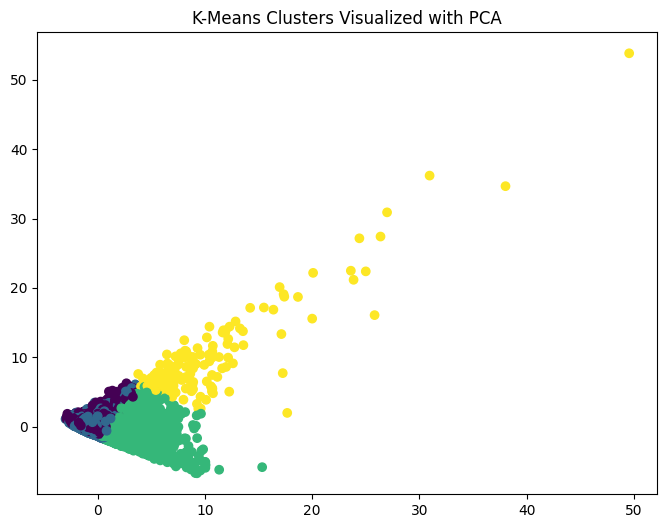

In [20]:
#kmeans vizualization using PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_Top_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_clusters)
plt.title("K-Means Clusters Visualized with PCA")

plt.show()
    

## 7. Model results

### Model Optimization Method

After some experimentation, I noticed that increasing the test-train split in .05 increments increased accuracy and recall. It kept rising until I hit .40, after which accuracy decreased for the first time. I decided to settle on .35, as it gave me the best results. I followed a similar process with n_estimators, increasing it in increments of 50, starting from n_estimators=50 and stopping at 200. For the K-means model, I added a few more features (from 5 to 8) to the mix and adjusted the k value to fit the new model (from 5 to 4).


In [ ]:

#random forest with out engineered features
#print('Statiscics of Random Forest without Engineered Features:\n')
#rf_wo_ef()

print('\nStatiscics of Random Forest Model:\n')
rf_w_ef()

print('\ntop 10 feature importances with engineered features:')
print(Feature_Importances.head(10))
time_w_ef = 37.4

print('\n k-means clustering mean analysis:\n')
print(cluster_summary_combined)


Statiscics of Random Forest with Engineered Features:

Accuracy: 0.8782285714285715
Precision: 1.0
Recall: 0.621020807398186
F1 Score: 0.7662095447065277

top 10 feature importances with engineered features:
Failed_Transaction_Count_7d    0.379722
7d_severity                    0.070661
Amount_to_Balance_Ratio        0.049064
Account_Balance                0.041244
Transaction_Amount             0.040755
user_transaction_avg_diff      0.040643
Transaction_Distance           0.040340
Amount_Diff_from_7d_Avg        0.039462
Avg_Transaction_Amount_7d      0.039136
device_distance_age_risk       0.038967
dtype: float64

 k-means clustering mean analysis:

         mean_train  mean_test  mean_diff
Cluster                                  
0          0.496083   0.492661   0.003422
1          0.155146   0.148651   0.006496
2          0.300595   0.306452  -0.005856
3          0.389222   0.444444  -0.055223


### Draft Versus Final Model Comparison

In [38]:
comparison_table = pd.DataFrame({
    'Model': ['Random Forest Model From Project Draft', 'Final Random Forest Model'],
    'Accuracy': [0.8772, accuracy_score(y_test, rf_predictions)],
    'Precision': [1.0, precision_score(y_test, rf_predictions)],
    'Recall': [0.617803, recall_score(y_test, rf_predictions)],
    'F1 Score': [0.763755, f1_score(y_test, rf_predictions)],
    'Time (seconds)': [25.2, time_w_ef] })

previus_model_metrics = pd.DataFrame({
    'Feature': [
        'Failed_Transaction_Count_7d',
        'Transaction_Distance',
        'Account_Balance',
        'Avg_Transaction_Amount_7d',
        'Amount_Deviation_from_7d_Avg',
        'Transaction_Amount',
        'Amount_to_Balance_Ratio',
        'Card_Age',
        'Daily_Transaction_Count',
        'Is_Weekend'
    ],
    'Importance': [
        0.432134,
        0.056033,
        0.054597,
        0.053576,
        0.053484,
        0.053468,
        0.053229,
        0.052524,
        0.033894,
        0.007933
    ]
})

print ('top ten features from draft model:') 
print(previus_model_metrics.head(10)) 

print ('\ntop ten features from final model:\n')
print(Feature_Importances.head(10))
print('\nModel Performance Comparison Draft Versus Final :\n')
comparison_table.head()


top ten features from draft model:
                        Feature  Importance
0   Failed_Transaction_Count_7d    0.432134
1          Transaction_Distance    0.056033
2               Account_Balance    0.054597
3     Avg_Transaction_Amount_7d    0.053576
4  Amount_Deviation_from_7d_Avg    0.053484
5            Transaction_Amount    0.053468
6       Amount_to_Balance_Ratio    0.053229
7                      Card_Age    0.052524
8       Daily_Transaction_Count    0.033894
9                    Is_Weekend    0.007933

top ten features from final model:

Failed_Transaction_Count_7d    0.379722
7d_severity                    0.070661
Amount_to_Balance_Ratio        0.049064
Account_Balance                0.041244
Transaction_Amount             0.040755
user_transaction_avg_diff      0.040643
Transaction_Distance           0.040340
Amount_Diff_from_7d_Avg        0.039462
Avg_Transaction_Amount_7d      0.039136
device_distance_age_risk       0.038967
dtype: float64

Model Performance Comparison

,Model,Accuracy,Precision,Recall,F1 Score,Time (seconds)
0,Random Forest Model From Project Draft,0.877200,1.0,0.617803,0.763755,25.2
1,Final Random Forest Model,0.878229,1.0,0.621021,0.766210,37.4


The new model runs slower than the draft but has increased accuracy, recall, and F1 score. With the addition of the new features, 7d_sevarity, user_transaction_avg_diff, and more were added to the top ten feature importances. While the new model is a bit slower, I think the newly found feature importances were extremely beneficial to the goal of identifying fraudulent transactions in real time.

In [23]:
cluster_profile = X_train_kmeans.groupby('Cluster').mean(numeric_only=True)
cluster_profile.head()

,Failed_Transaction_Count_7d,7d_severity,Amount_to_Balance_Ratio,Account_Balance,Transaction_Amount,user_transaction_avg_diff,Transaction_Distance,Amount_Diff_from_7d_Avg,Fraud_Label
Cluster,,,,,,,,,
0,0.856424,-0.055024,-0.149780,0.186436,-0.370773,0.351939,-0.047046,0.253072,0.496083
1,-0.865532,-0.155392,-0.108386,-0.149307,-0.381186,0.359644,0.047207,0.275124,0.155146
2,0.008647,0.198522,0.274655,-0.033998,1.590271,-1.505237,0.000222,-1.123761,0.300595
3,0.336581,9.365815,10.371883,-1.703793,1.584432,-1.486507,-0.017074,-0.869228,0.389222


## 8. Ethical Analysis & Responsible Deployment 


Any bias present in this data set is likely due to it being artificially constructed to simulate real world data. This may cause some results to be unrealistic and not reflect what real world data would show. Using a real world data set with similar values will solve this bias.
Both false positives and false negatives are harmful with this model. For example, if banks decide to use this model to detect fraud in real time, it will give them the opportunity to reduce fraud by taking steps such as locking cards or accounts to reduce the number of fraudulent transactions. Under these circumstances, a false positive will result in an account holder's card being unjustly locked. Situations such as these could be the result of an account holder being on vacation far from their normal location or making a purchase that is out of the norm, such as buying a car or other high-value purchases. False negatives, on the other hand, could cause a fraudulent transaction to go unnoticed, opening the opportunity for more fraudulent transactions to take place, thus increasing the loss that an account holder may incur. Out of the two situations, a false negative is the one that is potentially more harmful, as it may end up creating leeway for financial loss, while a false positive will only cause a slight hindrance for account holders that could be resolved with a phone call or a purchase confirmation in an app or by text.


## 8. Business Recommendations & Deployment Considerations

This model was developed to identify features that can predict the likelihood of transactions being fraudulent. By using this model, businesses such as banks and credit card companies can use the features discovered by the model to help identify fraudulent transactions in real time. To do this, a program can be used to identify and flag any transactions that have traits similar to past fraudulent ones. 

Once these transactions are identified, they can be separated for further monitoring or used to trigger a system that would put a hold on an account to reduce the number of fraudulent transactions that would otherwise be able to go through without any problem. A system such as this would be highly beneficial to companies as it would instill a sense of security in account and card holders. Further increasing client loyalty and trust as they would know that their money is safe.
